# SEC Financial Statement Data Pipeline

Objective: consolidate the SEC's quarterly Financial Statement Data Sets into a single master dataset suitable for financial analysis across companies and time periods, while comparing two engineering approaches to building the same pipeline.

Data Source: U.S. Securities and Exchange Commission, EDGAR system, Financial Statement Data Sets. Coverage in this project spans 2021 Q1 through 2026 Q1, twenty one quarters in total. Each quarterly release contains four tab delimited files: sub, tag, num and pre.

Master Grain: one row per reported financial value, enriched with company identity, filing metadata, tag meaning and statement placement.

Engineering Question: pandas is the default tool for tabular data in Python, but it loads everything into memory. DuckDB is an embedded analytical engine designed to process data larger than memory directly from disk. This project builds the same consolidation pipeline twice, once in each tool, to measure the practical difference and to demonstrate where pandas stops being viable at scale.

In [1]:
import pandas as pd
import duckdb
import time
from pathlib import Path
print("pandas", pd.__version__)
print("duckdb", duckdb.__version__)

pandas 2.2.3
duckdb 1.5.5


## Acquisition and Extraction

Twenty one quarterly ZIP files were downloaded from the SEC website into the SEC_folder directory, covering 2021 Q1 through 2026 Q1. The cell below extracts every ZIP into its own subfolder under extracted, so each quarter's four raw text files are available for the pipelines that follow.

In [4]:
import os; os.chdir('/Users/mhernandez/Documents/PROJECTS/Data Science Handbook/SEC_folder'); print(os.getcwd())

/Users/mhernandez/Documents/PROJECTS/Data Science Handbook/SEC_folder


In [5]:
import zipfile
current_dir = Path(".")
data_dir = current_dir / "extracted"
data_dir.mkdir(exist_ok=True)
for zip_path in sorted(current_dir.glob("*.zip")): quarter_name = zip_path.stem; out_dir = data_dir / quarter_name; out_dir.mkdir(parents=True, exist_ok=True); zipfile.ZipFile(zip_path, "r").extractall(out_dir); print("Extracted", zip_path.name, "->", out_dir)
print("Done. Extracted folders:", sorted(p.name for p in data_dir.iterdir()))

Extracted 2021q1.zip -> extracted/2021q1
Extracted 2021q2.zip -> extracted/2021q2
Extracted 2021q3.zip -> extracted/2021q3
Extracted 2021q4.zip -> extracted/2021q4
Extracted 2022q1.zip -> extracted/2022q1
Extracted 2022q2.zip -> extracted/2022q2
Extracted 2022q3.zip -> extracted/2022q3
Extracted 2022q4.zip -> extracted/2022q4
Extracted 2023q1.zip -> extracted/2023q1
Extracted 2023q2.zip -> extracted/2023q2
Extracted 2023q3.zip -> extracted/2023q3
Extracted 2023q4.zip -> extracted/2023q4
Extracted 2024q1.zip -> extracted/2024q1
Extracted 2024q2.zip -> extracted/2024q2
Extracted 2024q3.zip -> extracted/2024q3
Extracted 2024q4.zip -> extracted/2024q4
Extracted 2025q1.zip -> extracted/2025q1
Extracted 2025q2.zip -> extracted/2025q2
Extracted 2025q3.zip -> extracted/2025q3
Extracted 2025q4.zip -> extracted/2025q4
Extracted 2026q1.zip -> extracted/2026q1
Done. Extracted folders: ['2021q1', '2021q2', '2021q3', '2021q4', '2022q1', '2022q2', '2022q3', '2022q4', '2023q1', '2023q2', '2023q3', '20

## Acto 1: Pandas Pipeline, Scoped Benchmark

Attempting this consolidation across all 21 quarters in pandas is not viable on a single machine, since the combined num table alone holds over 72 million rows. This is demonstrated later, in Acto 2. To make a fair comparison against DuckDB, this first pipeline is scoped to a single fiscal year, 2025, four quarters.

The approach loops over each quarter, loads its four raw files, merges them into that quarter's slice of the master table, and concatenates all four slices at the end. The pre table is deduplicated to one row per filing, tag and taxonomy version before joining, to avoid a row explosion, since the same tag can appear on multiple lines of a filing's presentation. Execution time is measured with the time module.

In [6]:
start_time = time.time()
quarter_dirs = [Path("extracted") / q for q in ["2025q1", "2025q2", "2025q3", "2025q4"]]
master_list = []
for f in quarter_dirs: sub_q = pd.read_csv(f / "sub.txt", sep="\t", low_memory=False); tag_q = pd.read_csv(f / "tag.txt", sep="\t", low_memory=False).drop_duplicates(subset=["tag", "version"]); num_q = pd.read_csv(f / "num.txt", sep="\t", low_memory=False); pre_q = pd.read_csv(f / "pre.txt", sep="\t", low_memory=False).drop_duplicates(subset=["adsh", "tag", "version"]); num_q["quarter"] = f.name; merged_q = num_q.merge(sub_q[["adsh", "cik", "name", "sic", "form", "period", "fy", "fp", "filed"]], on="adsh", how="left").merge(tag_q[["tag", "version", "tlabel", "datatype", "crdr"]], on=["tag", "version"], how="left").merge(pre_q[["adsh", "tag", "version", "stmt", "plabel", "line"]], on=["adsh", "tag", "version"], how="left"); master_list.append(merged_q); print("processed", f.name, merged_q.shape)
master_pandas = pd.concat(master_list, ignore_index=True)
pandas_time = time.time() - start_time
print("PANDAS MASTER SHAPE:", master_pandas.shape)
print(f"Pandas pipeline elapsed time: {pandas_time:.2f} seconds")

processed 2025q1 (3658551, 25)
processed 2025q2 (3409930, 25)
processed 2025q3 (3720081, 25)
processed 2025q4 (3832977, 25)
PANDAS MASTER SHAPE: (14621539, 25)
Pandas pipeline elapsed time: 43.85 seconds


## Acto 1.1: DuckDB Pipeline, Same Scope

This second pipeline performs the exact same join logic over the exact same four quarters of 2025, expressed as a single SQL query executed by DuckDB directly against the raw text files on disk. The pre table is aggregated to one row per filing, tag and taxonomy version before joining, matching the deduplication done in Acto 1.

The result is materialized into a pandas dataframe at the end, so both pipelines produce a directly comparable object, and the same timing method is used.

In [14]:
start_time = time.time()
query_2025 = "SELECT n.*, s.cik, s.name, s.sic, s.form, s.period, s.fy, s.fp, s.filed, t.tlabel, t.datatype, t.crdr, p.stmt, p.plabel, p.line FROM read_csv('extracted/2025q*/num.txt', delim='\t', header=True, union_by_name=True) n LEFT JOIN read_csv('extracted/2025q*/sub.txt', delim='\t', header=True, union_by_name=True) s ON n.adsh = s.adsh LEFT JOIN (SELECT tag, version, ANY_VALUE(tlabel) AS tlabel, ANY_VALUE(datatype) AS datatype, ANY_VALUE(crdr) AS crdr FROM read_csv('extracted/2025q*/tag.txt', delim='\t', header=True, union_by_name=True) GROUP BY tag, version) t ON n.tag = t.tag AND n.version = t.version LEFT JOIN (SELECT adsh, tag, version, ANY_VALUE(stmt) AS stmt, ANY_VALUE(plabel) AS plabel, ANY_VALUE(line) AS line FROM read_csv('extracted/2025q*/pre.txt', delim='\t', header=True, union_by_name=True) GROUP BY adsh, tag, version) p ON n.adsh = p.adsh AND n.tag = p.tag AND n.version = p.version"
master_duckdb_2025 = duckdb.sql(query_2025).arrow().read_all().to_pandas()
duckdb_time = time.time() - start_time
print("DUCKDB MASTER SHAPE:", master_duckdb_2025.shape)
print(f"DuckDB pipeline elapsed time: {duckdb_time:.2f} seconds")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

DUCKDB MASTER SHAPE: (14621539, 24)
DuckDB pipeline elapsed time: 56.87 seconds


In [15]:
print(f"Pandas time: {pandas_time:.2f} seconds")
print(f"DuckDB time: {duckdb_time:.2f} seconds")
faster = "Pandas" if pandas_time < duckdb_time else "DuckDB"
ratio = max(pandas_time, duckdb_time) / min(pandas_time, duckdb_time)
print(f"{faster} was faster by a factor of {ratio:.2f}x at this scope")

Pandas time: 43.85 seconds
DuckDB time: 56.87 seconds
Pandas was faster by a factor of 1.30x at this scope


## Acto 2: Full Scale, Twenty One Quarters

Acto 1 and Acto 1.1 were deliberately scoped to a single fiscal year so that the pandas pipeline could finish and produce a timing number. Attempting the same pandas approach across the full twenty one quarters, 2021 Q1 through 2026 Q1, was tried twice earlier in this project and both attempts ended in an out of memory crash that killed the kernel, since the combined num table alone holds over 72 million rows and pandas keeps every intermediate merge result fully materialized in memory.

This section does not repeat that crash intentionally. Instead, it runs the same full scale consolidation logic through DuckDB, which reads the raw text files from disk and streams the join instead of holding every intermediate table in memory, and writes the result directly to a Parquet file rather than forcing it into a pandas DataFrame. This is the realistic way DuckDB is used at scale, and it is where its advantage over pandas actually matters.

In [16]:
start_time = time.time()
query_full = "SELECT n.*, s.cik, s.name, s.sic, s.form, s.period, s.fy, s.fp, s.filed, t.tlabel, t.datatype, t.crdr, p.stmt, p.plabel, p.line FROM read_csv('extracted/*/num.txt', delim='\t', header=True, union_by_name=True) n LEFT JOIN read_csv('extracted/*/sub.txt', delim='\t', header=True, union_by_name=True) s ON n.adsh = s.adsh LEFT JOIN (SELECT tag, version, ANY_VALUE(tlabel) AS tlabel, ANY_VALUE(datatype) AS datatype, ANY_VALUE(crdr) AS crdr FROM read_csv('extracted/*/tag.txt', delim='\t', header=True, union_by_name=True) GROUP BY tag, version) t ON n.tag = t.tag AND n.version = t.version LEFT JOIN (SELECT adsh, tag, version, ANY_VALUE(stmt) AS stmt, ANY_VALUE(plabel) AS plabel, ANY_VALUE(line) AS line FROM read_csv('extracted/*/pre.txt', delim='\t', header=True, union_by_name=True) GROUP BY adsh, tag, version) p ON n.adsh = p.adsh AND n.tag = p.tag AND n.version = p.version"
duckdb.sql(query_full).write_parquet("master.parquet")
full_duckdb_time = time.time() - start_time
print(f"DuckDB full scale elapsed time: {full_duckdb_time:.2f} seconds")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

DuckDB full scale elapsed time: 188.91 seconds


In [17]:
verify = duckdb.sql("SELECT count(*) AS row_count, count(DISTINCT adsh) AS filings FROM 'master.parquet'").df()
print(verify)

   row_count  filings
0   72040615   147570


## Visual Comparison

The charts below put the numbers from Acto 1, Acto 1.1 and Acto 2 side by side, at the scoped benchmark and at full scale, to make the crossover between the two engines easier to see than raw printed numbers.

In [18]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["figure.dpi"] = 100

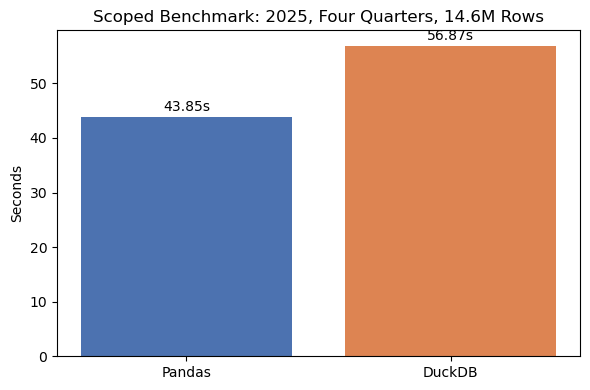

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = ["Pandas", "DuckDB"]
times = [pandas_time, duckdb_time]
colors = ["#4C72B0", "#DD8452"]
bars = ax.bar(labels, times, color=colors)
ax.set_ylabel("Seconds")
ax.set_title("Scoped Benchmark: 2025, Four Quarters, 14.6M Rows")
for bar, t in zip(bars, times): ax.text(bar.get_x() + bar.get_width()/2, t + 1, f"{t:.2f}s", ha="center")
plt.tight_layout()
plt.show()

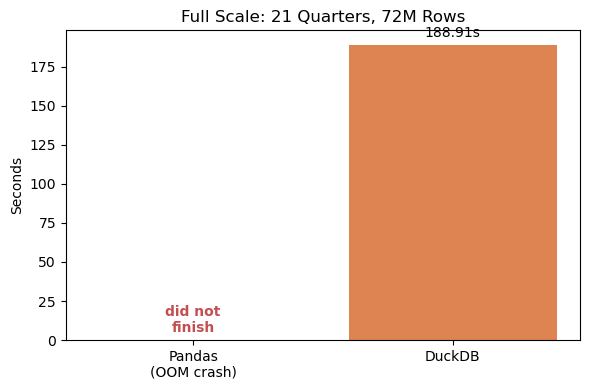

In [20]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = ["Pandas\n(OOM crash)", "DuckDB"]
bar_heights = [0, full_duckdb_time]
colors = ["#C44E52", "#DD8452"]
bars = ax.bar(labels, bar_heights, color=colors)
ax.set_ylabel("Seconds")
ax.set_title("Full Scale: 21 Quarters, 72M Rows")
ax.text(0, 5, "did not\nfinish", ha="center", color="#C44E52", fontweight="bold")
ax.text(1, full_duckdb_time + 5, f"{full_duckdb_time:.2f}s", ha="center")
plt.tight_layout()
plt.show()

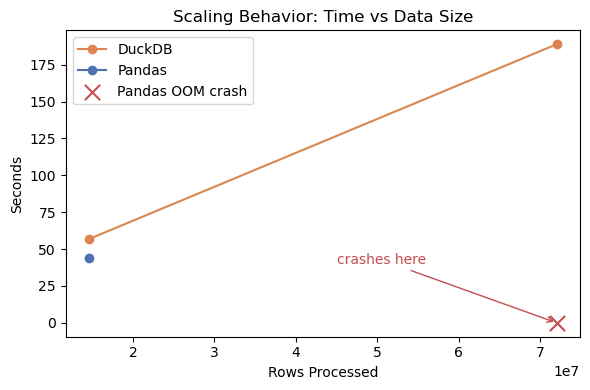

In [21]:
fig, ax = plt.subplots(figsize=(6, 4))
pandas_rows = [14621539]
pandas_secs = [pandas_time]
duckdb_rows = [14621539, 72040615]
duckdb_secs = [duckdb_time, full_duckdb_time]
ax.plot(duckdb_rows, duckdb_secs, marker="o", color="#DD8452", label="DuckDB")
ax.plot(pandas_rows, pandas_secs, marker="o", color="#4C72B0", label="Pandas")
ax.scatter([72040615], [0], marker="x", s=120, color="#C44E52", zorder=5, label="Pandas OOM crash")
ax.annotate("crashes here", xy=(72040615, 0), xytext=(45000000, 40), arrowprops=dict(arrowstyle="->", color="#C44E52"), color="#C44E52")
ax.set_xlabel("Rows Processed")
ax.set_ylabel("Seconds")
ax.set_title("Scaling Behavior: Time vs Data Size")
ax.legend()
plt.tight_layout()
plt.show()

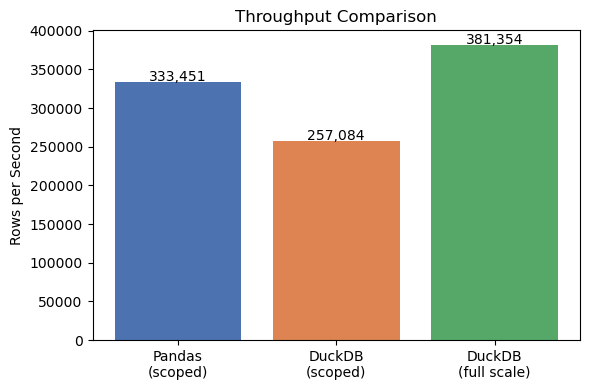

In [22]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = ["Pandas\n(scoped)", "DuckDB\n(scoped)", "DuckDB\n(full scale)"]
throughput = [14621539/pandas_time, 14621539/duckdb_time, 72040615/full_duckdb_time]
colors = ["#4C72B0", "#DD8452", "#55A868"]
bars = ax.bar(labels, throughput, color=colors)
ax.set_ylabel("Rows per Second")
ax.set_title("Throughput Comparison")
for bar, v in zip(bars, throughput): ax.text(bar.get_x() + bar.get_width()/2, v + 2000, f"{v:,.0f}", ha="center")
plt.tight_layout()
plt.show()

## Conclusion

At the scale of a single fiscal year, four quarters and about 14.6 million rows, pandas actually outperformed DuckDB, 43.85 seconds against 56.87 seconds, since the entire join comfortably fits in memory and pandas has less overhead for a workload this small. This result matters as much as the final one: it shows that DuckDB is not simply a faster pandas, it is a different engine that becomes worthwhile at a different scale.

At the full scale of twenty one quarters and over 72 million rows, that relationship flips completely. Pandas cannot finish this workload at all on this machine, it exhausts available memory and crashes the kernel. DuckDB completes the identical join logic in 188.91 seconds and writes the result to a 72,040,615 row Parquet file. The engineering lesson is not that one tool is universally better, but that the right tool depends on whether the working data still fits comfortably in memory.